## Analistes de Màrqueting i Comunicació: 
Com influeixen els dies de la setmana a l'efectivitat de les nostres campanyes de màrqueting, i quins dies haurien de ser prioritzats per maximitzar l'èxit de les nostres estratègies de contacte?

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

In [79]:
# Ruta del archivo CSV
ruta_archivo = r"c:\Users\marya\Downloads\clusters_agrupados_3_Week3"

# Cargar el archivo CSV (separado por comas)
df_BANK_marketing = pd.read_csv(ruta_archivo, sep=';')

In [80]:
meses = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}


df_BANK_marketing['num_mes'] = df_BANK_marketing['month'].str.lower().map(meses)

In [81]:
col = 'num_mes'
col_ref = 'month'  # columna de referencia
cols = list(df_BANK_marketing.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df_BANK_marketing = df_BANK_marketing[cols]

df_BANK_marketing.tail()

,id,age,job,marital,education,default,balance,housing,loan,contact,...,deposit,age_group,age_group2,job_cat,education_level,Cluster,balance_bins,balance_cat,cluster2,name_clusters
26171,26383,59.0,administrative,married,secondary,no,3735,no,no,cellular,...,yes,56 - 65,senior,profesional,media,0,"(2000.0, 81204.0]",Alto,0,Family
26172,26384,56.0,management,married,tertiary,no,6798,yes,no,cellular,...,no,56 - 65,senior,profesional,alta,4,"(2000.0, 81204.0]",Alto,2,Premium_Senior
26173,26385,40.0,administrative,single,secondary,no,50,no,no,cellular,...,yes,36 - 45,adulto,profesional,media,0,"(0.0, 500.0]",Bajo,0,Family
26174,26386,34.0,blue-collar,married,secondary,no,2994,yes,no,cellular,...,no,26 - 35,adulto_joven,operativo,media,3,"(2000.0, 81204.0]",Alto,1,Dynamic
26175,26387,31.0,services,single,secondary,no,13,no,yes,cellular,...,yes,26 - 35,adulto_joven,profesional,media,1,"(0.0, 500.0]",Bajo,1,Dynamic


In [82]:
saltos = []

for i in range(1, len(df_BANK_marketing)):
    mes_ant = df_BANK_marketing.loc[i-1, 'num_mes']
    mes_act = df_BANK_marketing.loc[i, 'num_mes']

    if mes_ant == 12 and mes_act == 1:   # diciembre → enero
        saltos.append(i)

# Mostrar los saltos encontrados
print("Saltos encontrados:", saltos)

Saltos encontrados: [1089, 3055, 12285, 16216, 23206, 25249, 25283]


In [83]:
df_BANK_marketing['año'] = 0

In [84]:
col = 'año'
col_ref = 'num_mes'  # columna de referencia
cols = list(df_BANK_marketing.columns)
cols.insert(cols.index(col_ref) + 1, cols.pop(cols.index(col)))
df_BANK_marketing = df_BANK_marketing[cols]



In [ ]:
# inicio hasta el primer salto → 2008
df_BANK_marketing.loc[:saltos[0]-1, 'año'] = 2008

# primer y segundo salto → 2009
df_BANK_marketing.loc[saltos[0]:saltos[1]-1, 'año'] = 2009

# segundo salto hasta el final → 2010
df_BANK_marketing.loc[saltos[1]:, 'año'] = 2010

In [86]:
df_1 = df_BANK_marketing.groupby('año').size()
df_1


año
2008     1089
2009     1966
2010    23121
dtype: int64

In [87]:
df_BANK_marketing['fecha'] = pd.to_datetime({
    'year': df_BANK_marketing['año'],
    'month': df_BANK_marketing['num_mes'],
    'day': df_BANK_marketing['day']
}, errors='coerce')

In [88]:
#Mapeamos 
dias = {
    'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes',
    'Saturday':'Sábado','Sunday':'Domingo'
}
#Sacamos el dia de la semana
df_BANK_marketing['dia_semana'] = df_BANK_marketing['fecha'].dt.day_name().map(dias)

In [89]:
df_BANK_marketing['dia_semana'].value_counts()

dia_semana
Viernes      5458
Jueves       5388
Miércoles    4844
Sábado       3921
Martes       3129
Domingo      2200
Lunes        1236
Name: count, dtype: int64

In [ ]:
# Contar total por día
total_por_dia = df_BANK_marketing.groupby('dia_semana').size()

# Contar sólo los yes
yes_por_dia = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes'].groupby('dia_semana').size()

# tasa de éxito
tasa_exito = (yes_por_dia / total_por_dia) * 100

# Ordenar los días 
orden = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
tasa_exito = tasa_exito.reindex(orden)

print(tasa_exito)


dia_semana
Lunes        91.343042
Martes       64.749121
Miércoles    49.174236
Jueves       48.645137
Viernes      45.767680
Sábado       30.247386
Domingo      22.181818
dtype: float64


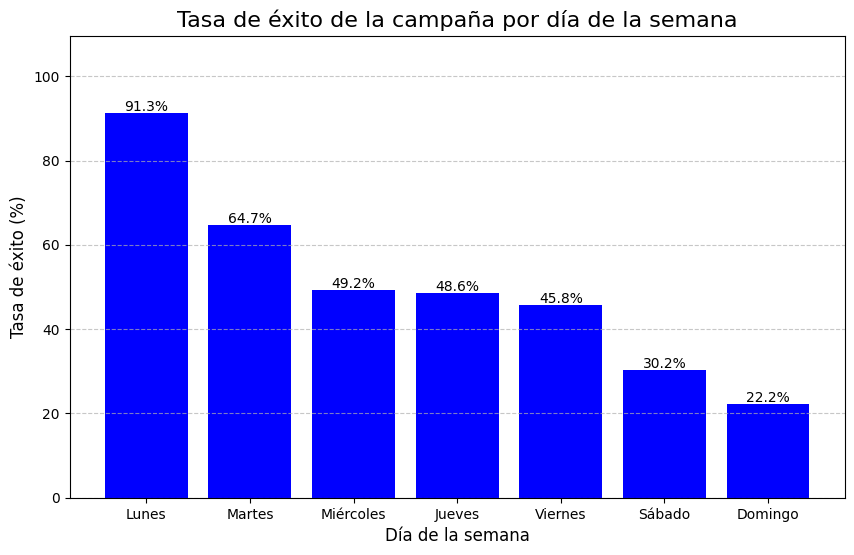

In [114]:
plt.figure(figsize=(10,6))
plt.bar(tasa_exito.index, tasa_exito.values, color='blue')
plt.title('Tasa de éxito de la campaña por día de la semana', fontsize=16)
plt.xlabel('Día de la semana', fontsize=12)
plt.ylabel('Tasa de éxito (%)', fontsize=12)
plt.ylim(0, max(tasa_exito.values)*1.2) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(tasa_exito.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10)

plt.show()

In [111]:
# Tabla de contingencia (día × yes/no)
tabla = pd.crosstab(df_BANK_marketing['dia_semana'],
                    df_BANK_marketing['deposit'])

print(tabla)


deposit       no   yes
dia_semana            
Domingo     1712   488
Jueves      2767  2621
Lunes        107  1129
Martes      1103  2026
Miércoles   2462  2382
Sábado      2735  1186
Viernes     2960  2498


In [113]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi-cuadrado:", chi2)
print("p-value:", p)



Chi-cuadrado: 2374.7951546412505
p-value: 0.0


In [115]:
df_lv = df_BANK_marketing[df_BANK_marketing['dia_semana'].isin(['Lunes', 'Viernes'])]


In [116]:

tabla_lv = pd.crosstab(df_lv['dia_semana'], df_lv['deposit'])
print(tabla_lv)


deposit       no   yes
dia_semana            
Lunes        107  1129
Viernes     2960  2498


In [118]:
chi2, p, dof, expected = chi2_contingency(tabla_lv)

print("Chi-cuadrado:", chi2)
print("p-value:", p)



Chi-cuadrado: 841.3768380432
p-value: 5.4484272611138856e-185


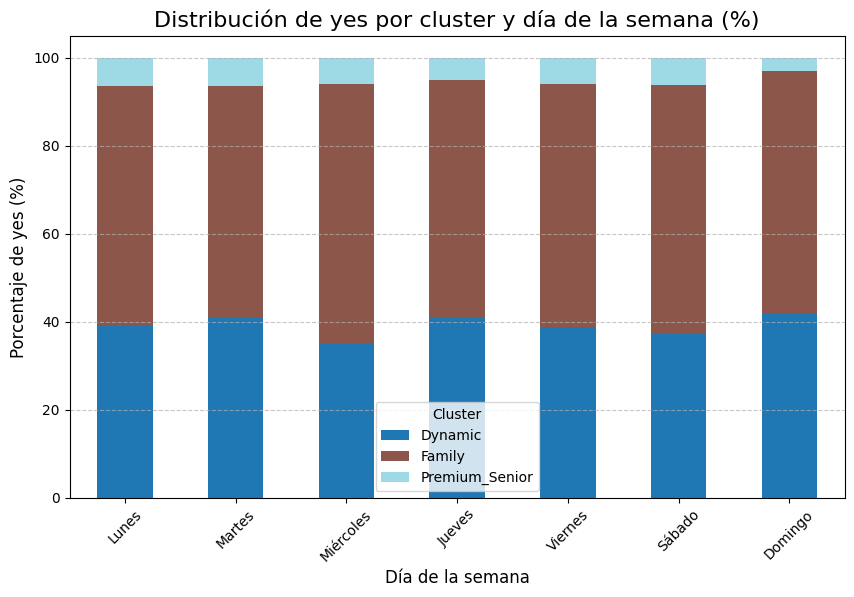

In [122]:

df_yes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']

df_grouped = df_yes.groupby(['dia_semana','name_clusters']).size().reset_index(name='cantidad')

# total de yes por día para porcentaje
total_por_dia = df_yes.groupby('dia_semana').size().to_dict()
df_grouped['porcentaje'] = df_grouped.apply(lambda row: row['cantidad']/total_por_dia[row['dia_semana']]*100, axis=1)

# ordenar los días de la semana
orden = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
df_grouped['dia_semana'] = pd.Categorical(df_grouped['dia_semana'], categories=orden, ordered=True)
df_grouped = df_grouped.sort_values(['dia_semana','name_clusters'])


# pivotamos para gráfico de barras apiladas

df_pivot = df_grouped.pivot(index='dia_semana', columns='name_clusters', values='porcentaje').fillna(0)

df_pivot.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab20')
plt.title('Distribución de yes por cluster y día de la semana (%)', fontsize=16)
plt.xlabel('Día de la semana', fontsize=12)
plt.ylabel('Porcentaje de yes (%)', fontsize=12)
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# Guardar como CSV 
import os
escritorio = os.path.join(os.path.expanduser("~"), "Desktop")
archivo = "dataset_final.csv"
ruta = os.path.join(escritorio, archivo)
df_BANK_marketing.to_excel(os.path.join(escritorio, "dataset_final.xlsx"), index=False)


print(f"Archivo guardado en: {ruta}")



Archivo guardado en: C:\Users\marya\Desktop\dataset_final.csv
